# Random Forest
Addestriamo nuovamente un modello come visto per la Logistic Regression usando il metodo delle Random Forests. Interpretiamo la domanda esattamente come espresso per la Logistic Regression.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn import datasets
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegressionCV, LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
#from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve
#from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, matthews_corrcoef, make_scorer
from sklearn import metrics

In [2]:
# da eliminare una volta unificati i branch
def get_AQI_inq(value, intervals):
    if pd.isna(value):
        return np.nan

    for i, (low, high) in enumerate(intervals):
        if low <= value < high:
            return 25 / (high - low) * (value - low) + 20 * i
               
    return np.nan

## Preparazione dataframe

In [3]:
# prepariamo il dataframe per questo studio (poi questa parte va probabilmente spostata)
dataset_df = pd.read_csv('../data/processed/dataset_EDA_processed.csv')
# voglio trasformare la data in un numero da 1 al massimo
dataset_df["date"] = pd.to_datetime(dataset_df["date"])
dataset_df["day"] = (dataset_df["date"] - dataset_df["date"].min()).dt.days + 1
dataset_df = dataset_df.drop(columns='date')

# cambiamo i giorni della settimana nel nome dei giorni
dataset_df["week_day"] = dataset_df["week_day"].astype(str)
day = {'0':'lunedì', '1':'martedì', '2':'mercoledì', '3':'giovedì', '4':'venerdì', '5':'sabato', '6':'domenica'}
dataset_df['week_day'] = dataset_df['week_day'].map(day)

# inseriamo l'AQI e togliamo le colonne di inquinanti non misurate da tutte le stazioni
inq_intervals = {'PM2.5':[(0, 10), (10, 20), (20, 25), (25, 30), (30, np.inf)], 
                'PM10':[(0, 20), (20, 35), (35, 50), (50, 100), (100, np.inf)],
                'NO2':[(0, 40), (40, 100), (100, 200), (200, 400), (400, np.inf)],
                'O3':[(0, 80), (80, 120), (120, 180), (180, 240), (240, np.inf)],
                'SO2':[(0, 100), (100, 200), (200, 350), (350, 500), (500, np.inf)],
                'CO':[(0, 5), (5, 7.5), (7.5, 10), (10, 20), (20, np.inf)]}

for inq in inq_intervals.keys():
    dataset_df['AQI_' + inq] = dataset_df[inq].apply(lambda x: get_AQI_inq(x, inq_intervals[inq]))

AQI_cols = ['AQI_' + inq for inq in inq_intervals.keys()]

dataset_df['AQI'] = dataset_df[AQI_cols].max(axis=1)
dataset_df = dataset_df.drop(columns=AQI_cols)
# devo togliere i nan => tolgo tutte le colonne di inquinanti che non sono misurati da tutte le stazioni (rimangono solo PM10 e NO2)
# se necessario, stiamo già tenendo conto del contributo degli altri inquinanti nell'AQI 
dataset_df = dataset_df.drop(columns=['CO', 'O3', 'PM2.5', 'SO2'])

# tengo solo le colonne che mi interessano
feature_cols = ['station_appa', 'day', 'hour', 'week_day', 'elevation', 'PM10', 'NO2', 'AQI', 'tot_area_power', 'temperature', 'precipitation']
dataset_df = dataset_df[feature_cols + ['EAQI']]

target = dataset_df['EAQI']

dataset_df.head()

,station_appa,day,hour,week_day,elevation,PM10,NO2,AQI,tot_area_power,temperature,precipitation,EAQI
0,Borgo Valsugana,1,23,venerdì,410,25.0,16.0,32.5,921.457256,10.0,0.0,fair
1,Borgo Valsugana,2,1,sabato,410,25.0,14.0,37.5,938.390584,10.1,0.0,fair
2,Borgo Valsugana,2,2,sabato,410,25.0,15.0,37.5,940.862870,10.0,0.0,fair
3,Borgo Valsugana,2,3,sabato,410,25.0,12.0,40.0,943.581445,10.2,0.0,fair
4,Borgo Valsugana,2,4,sabato,410,23.0,12.0,40.0,941.596837,10.0,0.0,fair


## Studio binario
Come spiegato nel notebook relativo alla regressione logistica, cominciamo l'analisi studiando una versione binaria del problema. In questo caso poniamo il threshold tra le due categorie di qualità dell'aria a 40, ovvero la soglia tra le categorie 'fair' e 'moderate'. 

In [4]:
threshold = 40
dataset_df['target'] = (dataset_df['AQI'] <= threshold).astype(int)
dataset_df = dataset_df.drop(columns='EAQI')
dataset_df.head()

,station_appa,day,hour,week_day,elevation,PM10,NO2,AQI,tot_area_power,temperature,precipitation,target
0,Borgo Valsugana,1,23,venerdì,410,25.0,16.0,32.5,921.457256,10.0,0.0,1
1,Borgo Valsugana,2,1,sabato,410,25.0,14.0,37.5,938.390584,10.1,0.0,1
2,Borgo Valsugana,2,2,sabato,410,25.0,15.0,37.5,940.862870,10.0,0.0,1
3,Borgo Valsugana,2,3,sabato,410,25.0,12.0,40.0,943.581445,10.2,0.0,1
4,Borgo Valsugana,2,4,sabato,410,23.0,12.0,40.0,941.596837,10.0,0.0,1


Costruiamo ora i dataframe che useremo effettivamente per addestrare il modello.

In [5]:
feature_df = dataset_df[feature_cols[:5]].copy()
for h in range (1,4):
    feature_df[[col + f'_{h}' for col in feature_cols[5:10]]] = dataset_df.groupby('station_appa')[feature_cols[5:10]].shift(h)
    feature_df[f'precipitation_{4 + h}'] = dataset_df.groupby('station_appa')[feature_cols[-1]].shift(5 + h)

# trasformiamo in one-hot le stazioni ed il giorno della settimana
feature_df = pd.get_dummies(feature_df, columns=['week_day'], prefix='', prefix_sep='')
feature_df = pd.get_dummies(feature_df, columns=['station_appa'], prefix='', prefix_sep='')

classification_df = feature_df.copy()
classification_df['target'] = dataset_df['target']
classification_df = classification_df.dropna(subset=['precipitation_7'])

feature_cols = classification_df.columns.difference(['target'])

# vediamo se ci sono righe con nan e togliamole
classification_df = classification_df[~classification_df.isna().any(axis=1)]

classification_df.head()

,day,hour,elevation,PM10_1,NO2_1,AQI_1,tot_area_power_1,temperature_1,precipitation_5,PM10_2,...,martedì,mercoledì,sabato,venerdì,Borgo Valsugana,Monte Gaza,Parco S. Chiara,Rovereto,Via Bolzano,target
8,2,8,410,23.0,16.0,25.000000,927.923195,9.6,0.0,23.0,...,False,False,True,False,True,False,False,False,False,1
9,2,9,410,24.0,21.0,26.666667,921.967223,9.9,0.0,23.0,...,False,False,True,False,True,False,False,False,False,1
10,2,10,410,29.0,19.0,35.000000,916.103636,10.3,0.0,24.0,...,False,False,True,False,True,False,False,False,False,1
11,2,11,410,29.0,23.0,35.000000,913.024411,11.0,0.0,29.0,...,False,False,True,False,True,False,False,False,False,1
12,2,12,410,27.0,23.0,31.666667,909.916536,11.4,0.4,29.0,...,False,False,True,False,True,False,False,False,False,1


In [6]:
# creo train e test, non ci sarà bisogno di valid siccome usiamo bootstrap e out of bag
X_train, X_test, y_train, y_test= train_test_split(classification_df[feature_cols], classification_df['target'], test_size=0.2, random_state=12)

# riscaliamo ponendo la media a 0 e la deviazione std a 1
non_num_features = ['day', 'hour', 'lunedì', 'martedì', 'mercoledì', 'giovedì', 'venerdì', 'sabato', 'domenica', 'Borgo Valsugana', 'Monte Gaza', 'Parco S. Chiara', 
                    'Rovereto', 'Via Bolzano']
num_features = X_train.columns.difference(non_num_features)

scaler = StandardScaler()
scaled_num_X_train = scaler.fit_transform(X_train[num_features])
scaled_num_X_test = scaler.transform(X_test[num_features])

scaled_X_train = X_train.copy()
scaled_X_test = X_test.copy()

scaled_X_train[num_features] = scaled_num_X_train
scaled_X_test[num_features] = scaled_num_X_test

scaled_X_train.head()

,AQI_1,AQI_2,AQI_3,Borgo Valsugana,Monte Gaza,NO2_1,NO2_2,NO2_3,PM10_1,PM10_2,...,precipitation_6,precipitation_7,sabato,temperature_1,temperature_2,temperature_3,tot_area_power_1,tot_area_power_2,tot_area_power_3,venerdì
4481,-0.494027,-0.508842,-0.635002,False,False,0.531191,0.502242,-0.068977,-0.668280,-0.624365,...,-0.203446,-0.204153,False,0.884977,1.070297,1.234716,0.261968,0.291952,0.317567,False
762,0.725489,0.947257,1.820469,True,False,-0.166898,-0.101756,-0.005424,0.856459,1.159965,...,-0.203446,-0.204153,False,-1.682592,-1.663495,-1.574727,-0.542594,-0.545691,-0.550840,False
2129,-0.666944,-0.690855,-0.580436,False,True,-1.245763,-1.246173,-1.244710,-1.001817,-1.010166,...,-0.203446,-0.204153,False,0.178306,-0.060927,-0.299854,-1.316289,-1.316471,-1.316610,False
5097,-0.694246,-0.363232,-0.034776,False,False,0.023490,0.247927,0.630107,-0.382392,-0.190339,...,-0.203446,-0.204153,False,0.508086,0.339715,-0.252636,0.450001,0.445460,0.441900,False
1208,1.817594,1.820917,1.820469,True,False,-0.325555,-0.292492,-0.259637,1.332940,1.256415,...,-0.203446,-0.204153,False,0.248973,0.221879,0.219539,-0.770440,-0.767931,-0.767515,False


In [7]:
# inizializziamo il classificatore
rfc_1 = RandomForestClassifier(n_estimators=200,          # numero di alberi
                                max_features='sqrt',      # numero di feature considerate per cercare lo split migliore
                                random_state=12,          # fissiamo il seed per maggiore riproducibilità
                                class_weight='balanced',  # bilancia in automatico le classi
                                n_jobs=-1,                # bilancia in automatico le classi in base alla frequenza di input
                                bootstrap=True,           # bootstrap e out-of-bag ci permettono di lavorare in modo simile alla cross validation
                                oob_score=True)

In [8]:
rfc_1.fit(scaled_X_train,y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200, n_jobs=-1,
                       oob_score=True, random_state=12)

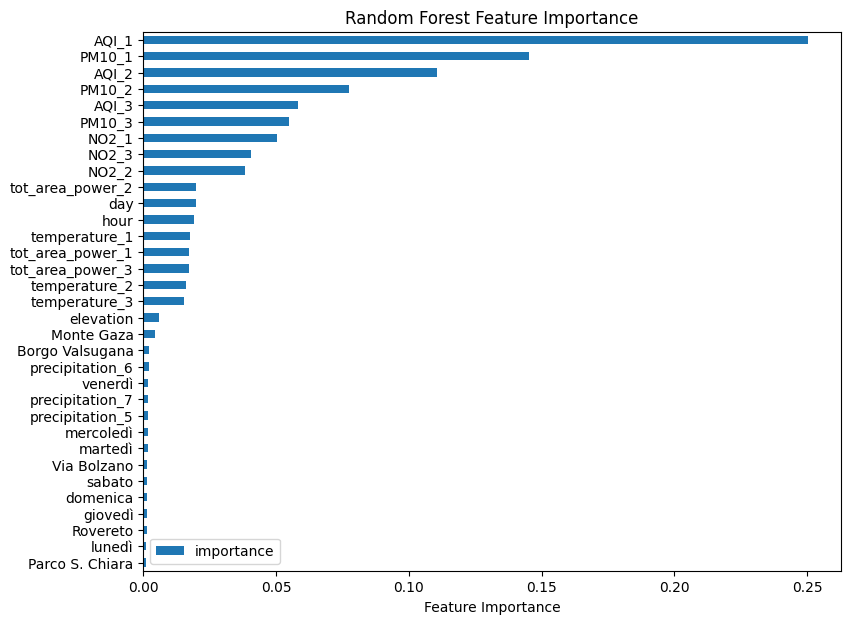

In [9]:
# quali feature sono più importanti?
classification_features = scaled_X_train.columns.difference(['target'])

df_importance_1 = pd.DataFrame({'importance': rfc_1.feature_importances_}, index=classification_features)

df_importance_1 = df_importance_1.sort_values(by='importance', ascending=True)

df_importance_1.plot.barh(figsize=(9,7))

plt.xlabel('Feature Importance')
plt.title('Random Forest Feature Importance')
plt.show()

Vediamo dall'immagine precedente che i fattori più importanti per il modello sono quelli relativi alle concentrazioni di inquinanti, e qualità dell'aria nelle ore precedenti. Anche potenza elettrica utilizzata, temperatura e orario sono feature rilevanti. D'altro canto, il giorno della settimana, le precipitazioni e la stazione di misurazione sono feature poco utili, che potrebbero probabilmente essere tagliate senza compromettere sensibilmente il modello.

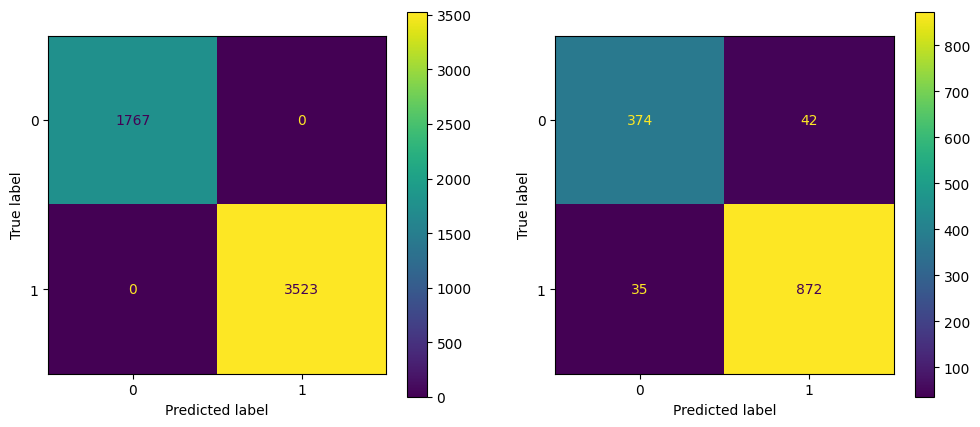

In [10]:
# disegnamo la confusion matrix in modo da capire se il nostro modello funziona o no
fig, axes = plt.subplots(1, 2, figsize=(12, 5))


y_pred_tr = rfc_1.predict(scaled_X_train)
metrics.ConfusionMatrixDisplay.from_predictions(y_train, y_pred_tr, display_labels=rfc_1.classes_, ax = axes[0]) # classes_ tira fuori i nomi delle classi

y_pred_te = rfc_1.predict(scaled_X_test)
metrics.ConfusionMatrixDisplay.from_predictions(y_test, y_pred_te, display_labels=rfc_1.classes_, ax = axes[1])


Vediamo che è possibile che stiamo commettendo overfitting siccome i nostri dati sono tutti correttamente classificati nel caso di train mentre in test abbiamo una frazione consistente (seppur ridotta) di falsi positivi e falsi negativi. In realtà un'accuratezza del 100% non è inusuale nel caso di una random forest senza constraint particolarmente stringenti; ad ogni modo, il modello rimane molto solido anche nell'insieme di test (accuratezza del 94%) e quindi immaginiamo che l'overfitting sia minimo e non intacchi significativamente la validità del modello all'infuori dell'insieme di test. Valutando la performance del nostro classificatore nell'insieme di test confermiamo la sua applicabilità.

In [12]:
# misuriamo la performance del nostro classificatore
accuracy    = metrics.accuracy_score    (y_test, y_pred_te) # pos_label indica la label positiva
precision   = metrics.precision_score   (y_test, y_pred_te)
recall      = metrics.recall_score      (y_test, y_pred_te)
f1_score    = metrics.f1_score          (y_test, y_pred_te)
MCC_score   = metrics.matthews_corrcoef (y_test, y_pred_te)

print(accuracy)
print(precision)
print(recall)
print(f1_score)
print(MCC_score)

0.9417989417989417
0.9540481400437637
0.9614112458654906
0.9577155409115871
0.8644523280100098


Una volta addestrato il modello disegnamo la curva ROC per cercare di scegliere un buon threshold.

In [1]:
y_proba = rfc_1.predict_proba(scaled_X_test)[:, 1] # restituisce le predizioni in forma di probabilità, quindi permette di disegnare la ROC
fpr,tpr,thr = metrics.roc_curve(y_test,y_proba,pos_label=1)
sns.set_context('talk')
ax = sns.lineplot(x=fpr, y=tpr)

ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.02])

ax.minorticks_on()
ax.grid(visible= True)
ax.yaxis.set_ticks_position("right")


ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')

ax.set_title('ROC Curve')

# dato che abbiamo molti dati, la curva sembra quasi smooth

NameError: name 'rfc_1' is not defined

In [14]:
# cerchiamo il threshold migliore cercando il punto più vicino a tpr=1, fpr=0
dist = np.sqrt((1 - tpr)**2 + fpr**2)

minimum_dist = dist.argmin()
best_thr = thr[minimum_dist]
print('Il threshold che massimizza la vicinanza al vertice è:', best_thr)

# per curiosità vediamo se differisce significativamente dal valore che otterremmo usando la statistica J di Youden
# J = tpr - fpr

J = tpr - fpr
maximum_J = J.argmax()
best_thr_J = thr[maximum_J]
print('Il threshold che massimizza la vicinanza al vertice è:', best_thr_J)

# bene, il threshold è lo stesso

Il threshold che massimizza la vicinanza al vertice è: 0.66
Il threshold che massimizza la vicinanza al vertice è: 0.66


Text(0.5, 1.0, 'PR Curve')

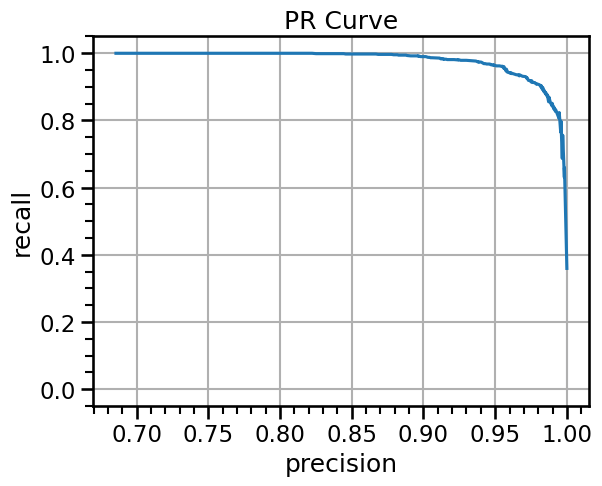

In [15]:
# plottiamo la curva precision-recall
prec,rec,thr = metrics.precision_recall_curve(y_test,y_proba,pos_label=1)
sns.set_context('talk')
ax = sns.lineplot(x=prec, y=rec)

ax.minorticks_on()
ax.grid(visible= True)

ax.set_xlabel('Precision')
ax.set_ylabel('Recall')

ax.set_title('PR Curve')

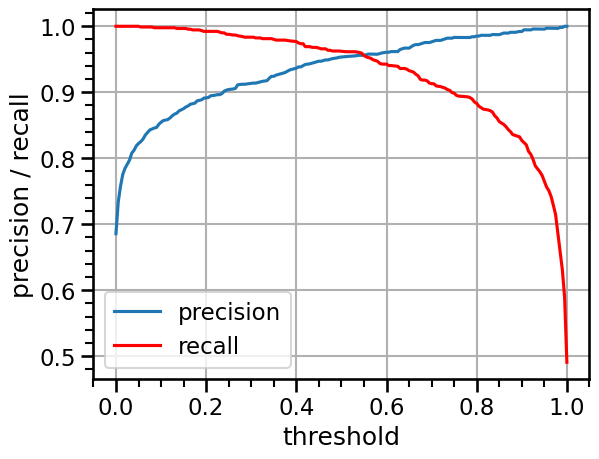

In [16]:
# disegnamo precision e recall separatamente al variare del threshold
ax = sns.lineplot(x=thr, y=prec[:-1], label='precision')
sns.lineplot(x=thr,y=rec[:-1],label='recall',color='red', ax=ax)
ax.set_xlabel('Threshold')
ax.set_ylabel('Precision / Recall')


ax.minorticks_on()
ax.grid(visible= True)

In [17]:
# un altro modo per scegliere il threshold consiste nel massimizzare il valore di F1
idx_1 = np.argmax(2 * (prec * rec) / (prec + rec))

thr_f1 = thr[idx_1]
prec_f1 = prec[idx_1]
rec_f1 = rec[idx_1]

print('Metodo di F1')
print('Threshold:', thr_f1)
print('Precision:', prec_f1)
print('Recall:', rec_f1)

# un altro modo (meno comune) per scegliere il threshold consiste nel trovare l'intersezione tra precision e recall, in modo da non preferire l'una
# rispetto all'altra
idx_2 = np.argmin(np.abs(prec[:-1] - rec[:-1]))

thr_intersection = thr[idx_2]
prec_intersection = prec[idx_2]
rec_intersection = rec[idx_2]

print("Metodo dell'intersezione")
print('Threshold:', thr_intersection)
print('Precision:', prec_intersection)
print('Recall:', rec_intersection)

# I due threshold sono molto vicini tra loro (non inatteso, i due metodi sono molto simili) ma distano dal threshold trovato con la ROC

Metodo di F1
Threshold: 0.53
Precision: 0.9550930996714129
Recall: 0.9614112458654906
Metodo dell'intersezione
Threshold: 0.55
Precision: 0.9558985667034179
Recall: 0.9558985667034179


I threshold trovati con metodi differenti sono relativamente simili, il che è positivo poiché threshold significativamente diversi potrebbero essere indice di una bassa stabilità del modello. In ultima istanza, siccome le nostre classi non sono ben bilanciate e poiché non abbiamo preferenze tra falsi positivi e falsi negativi, scegliamo il coefficiente di correlazione di Matthews come metrica da massimizzare ottimizzando il threshold.

In [19]:
thresholds = np.linspace(0, 1, 1001)

best_mcc = -1
best_threshold = None

for t in thresholds:
    y_pred = (y_proba >= t).astype(int)

    mcc = metrics.matthews_corrcoef(y_test, y_pred)

    if mcc > best_mcc:
        best_mcc = mcc
        best_threshold = t

print('Il threshold che migliore è ', best_threshold, ' poiché produce il valore massimo di MCC = ', best_mcc)

Il threshold che migliore è  0.531  poiché produce il valore massimo di MCC =  0.8664312165558252


# ATTENZIONE: non so se questo ragionamento è teoricamente corretto, stiamo ottimizzando il threshold su test, mentre è una cosa che andrebbe fatta su valid visto che test deve servire unicamente ad ottenere $E_{out}$

## Studio a 5 classi

Dopo questo primo esercizio, operiamo un lavoro più fine, lavorando direttamente sulle 5 classi di qualità dell'aria. 

### Preparazione dataframe

In [21]:
# prepariamo il dataframe per questo studio (poi questa parte va probabilmente spostata)
dataset_df = pd.read_csv('../data/processed/dataset_EDA_processed.csv')
# voglio trasformare la data in un numero da 1 al massimo
dataset_df["date"] = pd.to_datetime(dataset_df["date"])
dataset_df["day"] = (dataset_df["date"] - dataset_df["date"].min()).dt.days + 1
dataset_df = dataset_df.drop(columns='date')

# cambiamo i giorni della settimana nel nome dei giorni
dataset_df["week_day"] = dataset_df["week_day"].astype(str)
day = {'0':'lunedì', '1':'martedì', '2':'mercoledì', '3':'giovedì', '4':'venerdì', '5':'sabato', '6':'domenica'}
dataset_df['week_day'] = dataset_df['week_day'].map(day)

# inseriamo l'AQI e togliamo le colonne di inquinanti non misurate da tutte le stazioni
inq_intervals = {'PM2.5':[(0, 10), (10, 20), (20, 25), (25, 30), (30, np.inf)], 
                'PM10':[(0, 20), (20, 35), (35, 50), (50, 100), (100, np.inf)],
                'NO2':[(0, 40), (40, 100), (100, 200), (200, 400), (400, np.inf)],
                'O3':[(0, 80), (80, 120), (120, 180), (180, 240), (240, np.inf)],
                'SO2':[(0, 100), (100, 200), (200, 350), (350, 500), (500, np.inf)],
                'CO':[(0, 5), (5, 7.5), (7.5, 10), (10, 20), (20, np.inf)]}

for inq in inq_intervals.keys():
    dataset_df['AQI_' + inq] = dataset_df[inq].apply(lambda x: get_AQI_inq(x, inq_intervals[inq]))

AQI_cols = ['AQI_' + inq for inq in inq_intervals.keys()]

dataset_df['AQI'] = dataset_df[AQI_cols].max(axis=1)
dataset_df = dataset_df.drop(columns=AQI_cols)
# devo togliere i nan => tolgo tutte le colonne di inquinanti che non sono misurati da tutte le stazioni (rimangono solo PM10 e NO2)
# se necessario, stiamo già tenendo conto del contributo degli altri inquinanti nell'AQI 
dataset_df = dataset_df.drop(columns=['CO', 'O3', 'PM2.5', 'SO2'])

# tengo solo le colonne che mi interessano
feature_cols = ['station_appa', 'day', 'hour', 'week_day', 'elevation', 'PM10', 'NO2', 'AQI', 'tot_area_power', 'temperature', 'precipitation']
dataset_df = dataset_df[feature_cols + ['EAQI']]

target = dataset_df['EAQI']

dataset_df.head()

,station_appa,day,hour,week_day,elevation,PM10,NO2,AQI,tot_area_power,temperature,precipitation,EAQI
0,Borgo Valsugana,1,23,venerdì,410,25.0,16.0,32.5,921.457256,10.0,0.0,fair
1,Borgo Valsugana,2,1,sabato,410,25.0,14.0,37.5,938.390584,10.1,0.0,fair
2,Borgo Valsugana,2,2,sabato,410,25.0,15.0,37.5,940.862870,10.0,0.0,fair
3,Borgo Valsugana,2,3,sabato,410,25.0,12.0,40.0,943.581445,10.2,0.0,fair
4,Borgo Valsugana,2,4,sabato,410,23.0,12.0,40.0,941.596837,10.0,0.0,fair


In [22]:
# vogliamo prevedere l'EAQI ad un'ora date le informazioni sulle ore precedenti
# per evitare di appesantire troppo il dataframe consideriamo solo le tre ore precedenti per tutti i dati eccetto le precipitazioni
# abbiamo visto una correlasione particolare per gli inquinanti con le precipitazioni dalle 5 ore prima in poi. Per questo dato prendiamo quindi le precipitazioni
# di 5, 6 e 7 ore prima (invece che delle tre ore appena precedenti)

feature_df = dataset_df[feature_cols[:5]].copy()
for h in range (1,4):
    feature_df[[col + f'_{h}' for col in feature_cols[5:10]]] = dataset_df.groupby('station_appa')[feature_cols[5:10]].shift(h)
    feature_df[f'precipitation_{4 + h}'] = dataset_df.groupby('station_appa')[feature_cols[-1]].shift(5 + h)

# trasformiamo in one-hot le stazioni ed il giorno della settimana
feature_df = pd.get_dummies(feature_df, columns=['week_day'], prefix='', prefix_sep='')
feature_df = pd.get_dummies(feature_df, columns=['station_appa'], prefix='', prefix_sep='')

classification_df = feature_df.copy()
classification_df['target'] = target
classification_df = classification_df.dropna(subset=['precipitation_7'])

classification_features = classification_df.columns.difference(['target'])

classification_df.head()

,day,hour,elevation,PM10_1,NO2_1,AQI_1,tot_area_power_1,temperature_1,precipitation_5,PM10_2,...,martedì,mercoledì,sabato,venerdì,Borgo Valsugana,Monte Gaza,Parco S. Chiara,Rovereto,Via Bolzano,target
8,2,8,410,23.0,16.0,25.000000,927.923195,9.6,0.0,23.0,...,False,False,True,False,True,False,False,False,False,fair
9,2,9,410,24.0,21.0,26.666667,921.967223,9.9,0.0,23.0,...,False,False,True,False,True,False,False,False,False,fair
10,2,10,410,29.0,19.0,35.000000,916.103636,10.3,0.0,24.0,...,False,False,True,False,True,False,False,False,False,fair
11,2,11,410,29.0,23.0,35.000000,913.024411,11.0,0.0,29.0,...,False,False,True,False,True,False,False,False,False,fair
12,2,12,410,27.0,23.0,31.666667,909.916536,11.4,0.4,29.0,...,False,False,True,False,True,False,False,False,False,fair


In [23]:
# vediamo se ci sono righe con nan e togliamole
classification_df = classification_df[~classification_df.isna().any(axis=1)]
classification_df.head()

,day,hour,elevation,PM10_1,NO2_1,AQI_1,tot_area_power_1,temperature_1,precipitation_5,PM10_2,...,martedì,mercoledì,sabato,venerdì,Borgo Valsugana,Monte Gaza,Parco S. Chiara,Rovereto,Via Bolzano,target
8,2,8,410,23.0,16.0,25.000000,927.923195,9.6,0.0,23.0,...,False,False,True,False,True,False,False,False,False,fair
9,2,9,410,24.0,21.0,26.666667,921.967223,9.9,0.0,23.0,...,False,False,True,False,True,False,False,False,False,fair
10,2,10,410,29.0,19.0,35.000000,916.103636,10.3,0.0,24.0,...,False,False,True,False,True,False,False,False,False,fair
11,2,11,410,29.0,23.0,35.000000,913.024411,11.0,0.0,29.0,...,False,False,True,False,True,False,False,False,False,fair
12,2,12,410,27.0,23.0,31.666667,909.916536,11.4,0.4,29.0,...,False,False,True,False,True,False,False,False,False,fair


In [24]:
# separiamo train da test; siccome usiamo la cross-validation non c'è bisogno di scegliere esplicitamente valid
train, test = train_test_split(classification_df, test_size=0.20, random_state=12)
non_num_cols = ['day', 'hour', 'lunedì', 'martedì', 'mercoledì', 'giovedì', 'venerdì', 'sabato', 'domenica', 'Borgo Valsugana', 'Monte Gaza', 
                'Parco S. Chiara', 'Rovereto', 'Via Bolzano', 'target']
num_features = train.columns.difference(non_num_cols)

scaler = StandardScaler()
scaled_num_train = scaler.fit_transform(train[num_features])
scaled_num_test = scaler.transform(test[num_features])

scaled_train = train.copy()
scaled_test = test.copy()

scaled_train[num_features] = scaled_num_train
scaled_test[num_features] = scaled_num_test

# rimuoviamo il target dal dataframe con le features

scaled_train = scaled_train.drop(columns='target')
scaled_test = scaled_test.drop(columns='target')

scaled_train.head()

,day,hour,elevation,PM10_1,NO2_1,AQI_1,tot_area_power_1,temperature_1,precipitation_5,PM10_2,...,lunedì,martedì,mercoledì,sabato,venerdì,Borgo Valsugana,Monte Gaza,Parco S. Chiara,Rovereto,Via Bolzano
4481,20,19,-0.902186,-0.668280,0.531191,-0.494027,0.261968,0.884977,-0.207548,-0.624365,...,False,False,True,False,False,False,False,False,True,False
762,35,4,1.660514,0.856459,-0.166898,0.725489,-0.542594,-1.682592,-0.207548,1.159965,...,False,False,False,False,False,True,False,False,False,False
2129,38,12,-0.295557,-1.001817,-1.245763,-0.666944,-1.316289,0.178306,-0.207548,-1.010166,...,False,False,False,False,False,False,True,False,False,False
5097,47,14,-0.902186,-0.382392,0.023490,-0.694246,0.450001,0.508086,-0.207548,-0.190339,...,False,True,False,False,False,False,False,False,True,False
1208,54,15,1.660514,1.332940,-0.325555,1.817594,-0.770440,0.248973,-0.207548,1.256415,...,False,True,False,False,False,True,False,False,False,False


### Addestramento preliminare modello

Inizialmente scegliamo gli iperparametri in modo arbitrario, successivamente useremo GridSearchCV per trovare i valori ottimali per gli iperparametri.

In [25]:
# prepariamo il Random Forest
rfc_5 = RandomForestClassifier(n_estimators=200,          # numero di alberi
                                max_features="sqrt",      # massimo numero di feature considerate per lo split
                                random_state=12,
                                class_weight='balanced',  # bilancia in automatico le classi
                                n_jobs=-1,                # bilancia in automatico le classi in base alla frequenza di input
                                bootstrap=True,           # bootstrap e out-of-bag ci permettono di lavorare in modo simile alla cross validation
                                oob_score=True)

In [27]:
rfc_5.fit(scaled_train,train['target'])

RandomForestClassifier(class_weight='balanced', n_estimators=200, n_jobs=-1,
                       oob_score=True, random_state=12)

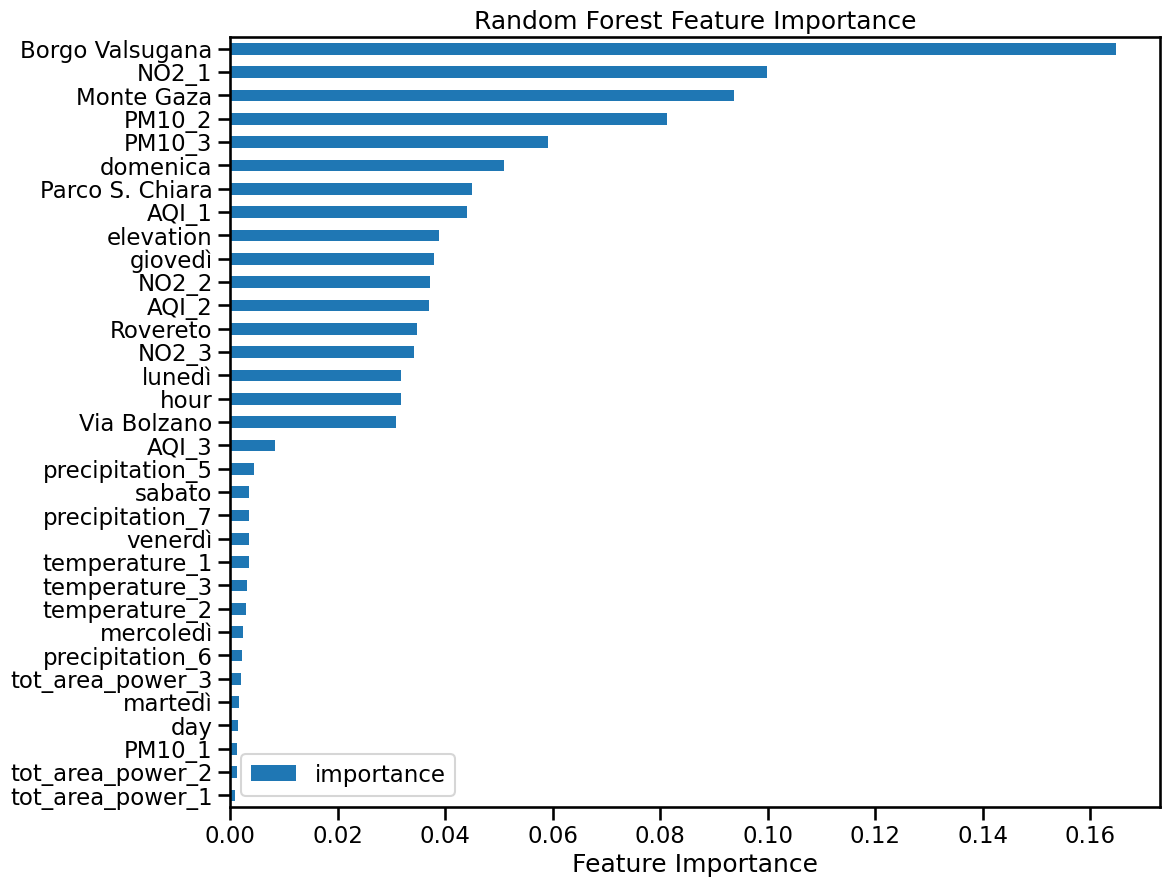

In [34]:
# quali feature sono più importanti?
df_importance = pd.DataFrame({'importance': rfc_5.feature_importances_}, index=classification_features)

df_importance = df_importance.sort_values(by='importance', ascending=True)

df_importance.plot.barh(figsize=(12,10))

plt.xlabel('Feature Importance')
plt.title('Random Forest Feature Importance')
plt.show()

Notiamo che le feature più importanti sono cambiate molto rispetto a prima.

In [10]:
# potevamo fittare meglio i dati? 
rfc.fit(scaled_train,train['target'])
rfc.score(scaled_train,train['target'])

1.0

L'accuratezza del modello rispetto ai dati dell'insieme di training è massima. Questo è positivo, tuttavia potrebbe essere dovuto all'overfitting dei nostri dati. Tracciamo le matrici di confusione sui dati dell'insieme di test.

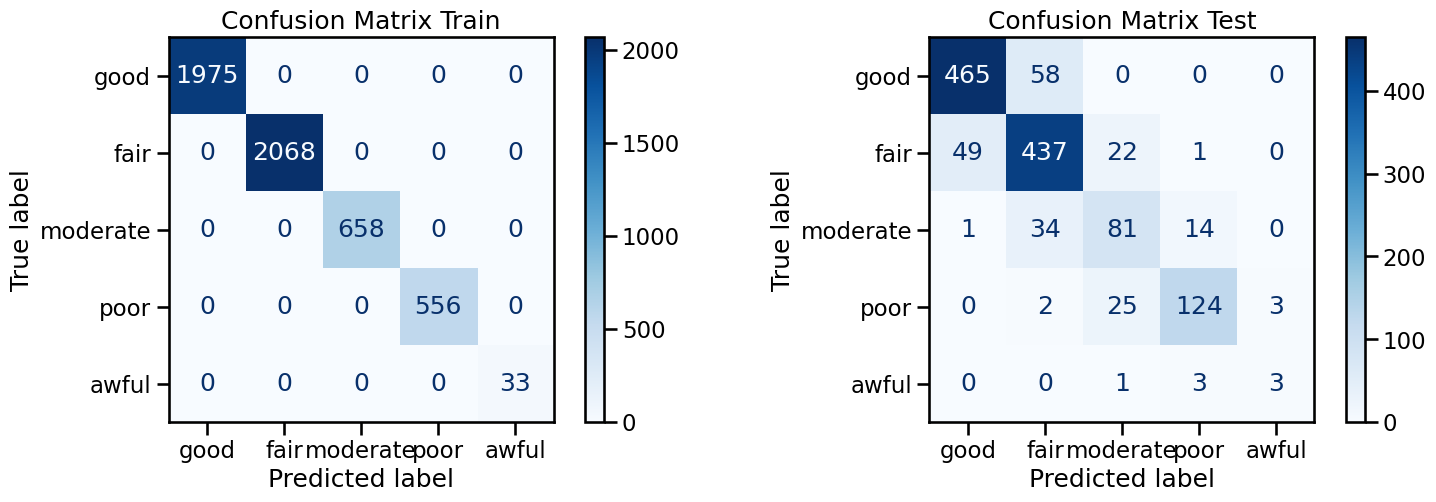

In [39]:
# diamo un'occhiata alla matrice di confusione
eaqi_order = ['good', 'fair', 'moderate', 'poor', 'awful']

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

metrics.ConfusionMatrixDisplay.from_estimator(rfc_5, scaled_train, train['target'], cmap='Blues', labels=eaqi_order, ax = axes[0])
metrics.ConfusionMatrixDisplay.from_estimator(rfc_5, scaled_test, test['target'], cmap='Blues', labels=eaqi_order, ax = axes[1])

axes[0].set_title('Confusion Matrix Train')
axes[1].set_title('Confusion Matrix Test')

plt.show()

Vediamo che effettivamente la precisione si riduce significativamente quando ci spostiamo al di fuori dell'insieme di training. Fortunatamente la precisione rimane buona anche nell'insieme di testing. Tuttavia, per la categoria 'awful' si ha un'accuratezza pessima poiché la classe è molto più piccola rispetto alle altre. Utilizzare class_weight='balanced' potrebbe risolvere il problema. Nella sezione successiva metteremo alla prova questa ipotesi quando utilizzeremo il GridSearchCV.

Poiché stiamo lavorando su cinque classi sbilanciate, la metrica migliore per valutare il modello è il Matthews Correlation Coefficient.

In [42]:
mcc = metrics.matthews_corrcoef(test['target'], rfc_5.predict(scaled_test))
mcc

0.7597952431065216

### Ottimizzazione iper-parametri

In [45]:
param_grid = {'n_estimators': [50, 100, 200, 500],
                'max_depth': [2, 5, 10, None],
                'min_samples_leaf': [1, 2, 5],
                'class_weight': [None, 'balanced']}

rfc_cv = GridSearchCV(RandomForestClassifier(random_state=12),
                    param_grid,
                    scoring=metrics.make_scorer(metrics.matthews_corrcoef),       # come spiegato prima, usiamo mcc come parametro da ottimizzare
                    cv=5,
                    n_jobs=-1)

In [46]:
rfc_cv.fit(scaled_train, train['target'])

print(grid.best_params_)

{'class_weight': None, 'max_depth': None, 'min_samples_leaf': 2, 'n_estimators': 500}


Notiamo che, al contrario da quanto ipotizzato precedentemente, il valore ottimale di class_weight non è 'balanced'. Questo probabilmente è dovuto al fatto che la classe awful è talmente piccola che il guadagno ottenuto ponendo i pesi delle classi a 'balanced' è poco significativo rispetto alla perdita di accuratezza sulle altre classi.

In [48]:
# diamo un'occhiata alle altre combinazioni di iper-parametri
results = pd.DataFrame(rfc_cv.cv_results_)

results.sort_values(by='mean_test_score', ascending=False).head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_class_weight,param_max_depth,param_min_samples_leaf,param_n_estimators,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
43,5.856592,0.120227,0.125255,0.013087,None,None,2,500,"{'class_weight': None, 'max_depth': None, 'min...",0.729684,0.720819,0.771745,0.776913,0.760954,0.752023,0.022632,1
89,1.323299,0.027120,0.033363,0.002262,balanced,None,2,100,"{'class_weight': 'balanced', 'max_depth': None...",0.742644,0.725338,0.765770,0.772747,0.751134,0.751527,0.016841,2
42,2.354098,0.110795,0.056359,0.004781,None,None,2,200,"{'class_weight': None, 'max_depth': None, 'min...",0.735429,0.718075,0.767268,0.774092,0.761161,0.751205,0.021107,3
41,1.123457,0.021903,0.028450,0.000278,None,None,2,100,"{'class_weight': None, 'max_depth': None, 'min...",0.728120,0.729454,0.767298,0.768424,0.762425,0.751144,0.018370,4
38,2.359359,0.014644,0.050639,0.001479,None,None,1,200,"{'class_weight': None, 'max_depth': None, 'min...",0.736643,0.708377,0.773235,0.782824,0.751492,0.750514,0.026567,5


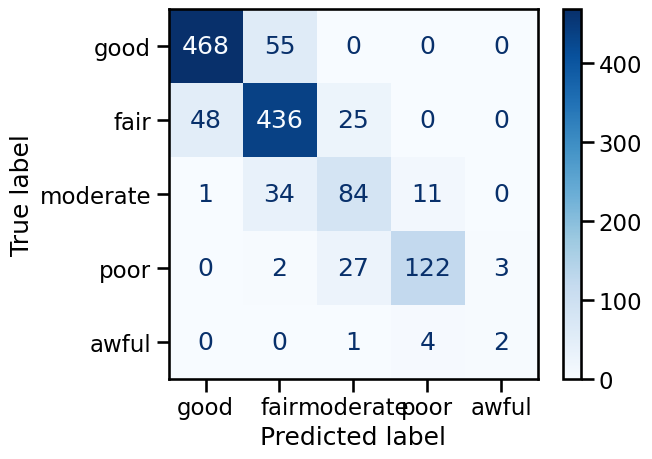

In [52]:
rfc_best = rfc_cv.best_estimator_
metrics.ConfusionMatrixDisplay.from_estimator(rfc_best, scaled_test, test['target'], cmap='Blues', labels=eaqi_order)

In [51]:
new_mcc = print(rfc_cv.best_score_)

0.7520228782818345


In conclusione, questo modello è piuttosto buono (mcc = 0.75) ma, poiché si concentra su un problema a 5 classi che è chiaramente più complesso rispetto ad un problema a 2 classi, produce previsioni meno affidabili rispetto a prima.